# OG vs Auxiliary EGOP — Results Analysis

Loads per-rsvd CSVs from `results/csv/`, produces comparison plots
and a summary table. Visual style borrowed from cluster23 plot.py.

In [1]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

# plot_aux_v2.py lives in results/utils/ — add that to sys.path so we can import it
sys.path.insert(0, str(Path.cwd() / 'utils'))

import pandas as pd
import matplotlib.pyplot as plt

import plot_aux_v2 as pa

pa.setup_fonts()

## 1. Load CSVs

In [ ]:
CSV_DIR = 'csv/FashionMNIST_aux'  # relative to results/

# Auto-detect all rsvd values
df = pa.load_results(CSV_DIR)
df.head()

In [3]:
# Or specify a subset
rsvd_values = [50, 100, 200, 400, 800, 1000, 2000, 4000, 7940]
df = pa.load_results(CSV_DIR, rsvd_values=rsvd_values)

  loaded rsvd=   50  (og_vs_aux_rsvd50_20260513_120921.csv, 10000 rows, 50 trials)
  loaded rsvd=  100  (og_vs_aux_rsvd100_20260513_120638.csv, 10000 rows, 50 trials)
  loaded rsvd=  200  (og_vs_aux_rsvd200_20260513_121048.csv, 10000 rows, 50 trials)
  loaded rsvd=  400  (og_vs_aux_rsvd400_20260520_093933.csv, 10000 rows, 50 trials)
  loaded rsvd=  800  (og_vs_aux_rsvd800_20260520_103814.csv, 10000 rows, 50 trials)
  loaded rsvd= 1000  (og_vs_aux_rsvd1000_20260513_123905.csv, 10000 rows, 50 trials)
  loaded rsvd= 2000  (og_vs_aux_rsvd2000_20260520_115253.csv, 10000 rows, 50 trials)
  loaded rsvd= 4000  (og_vs_aux_rsvd4000_20260513_122623.csv, 10000 rows, 50 trials)
  loaded rsvd= 7940  (og_vs_aux_rsvd7940_20260513_122801.csv, 10000 rows, 50 trials)


## 2. Summary table

In [4]:
summary = pa.summary_table(df, rsvd_values=rsvd_values)
summary.style.format({
    'val_acc_mean': '{:.4f}',
    'val_acc_std': '{:.4f}',
    'train_acc_mean': '{:.4f}',
    'total_time_mean': '{:.1f}',
    'total_time_std': '{:.1f}',
})

,rsvd,model,n_trials,val_acc_mean,val_acc_std,train_acc_mean,total_time_mean,total_time_std
0,50,og,50,0.8780,0.0059,0.9122,87.5,0.9
1,50,aux_egop,50,0.8820,0.0061,0.9221,101.6,1.4
2,100,og,50,0.8780,0.0059,0.9122,85.7,1.2
3,100,aux_egop,50,0.8834,0.0055,0.9365,99.3,1.0
4,200,og,50,0.8780,0.0059,0.9122,87.2,1.1
5,200,aux_egop,50,0.8857,0.0048,0.9264,100.4,1.5
6,400,og,50,0.8780,0.0059,0.9122,83.5,1.5
7,400,aux_egop,50,0.8835,0.0043,0.9573,96.3,1.9
8,800,og,50,0.8780,0.0059,0.9122,107.0,2.3
9,800,aux_egop,50,0.8843,0.0038,0.9410,122.7,2.6


## 3. Validation accuracy curves

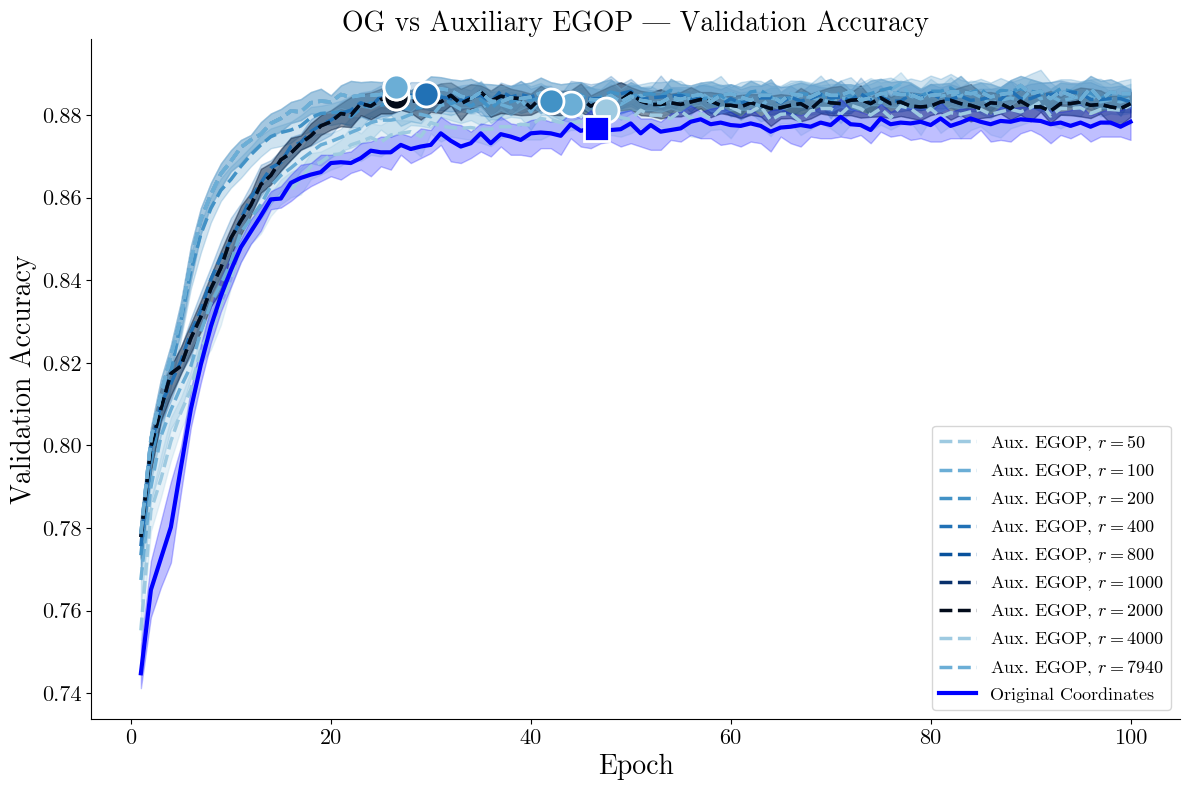

In [5]:
fig, ax = plt.subplots(figsize=(12, 8))
pa.plot_val_acc_curves(df, rsvd_values=rsvd_values, ax=ax)
plt.tight_layout()
plt.savefig('figures/aux_v2_val_acc_curves.pdf', bbox_inches='tight')
plt.show()

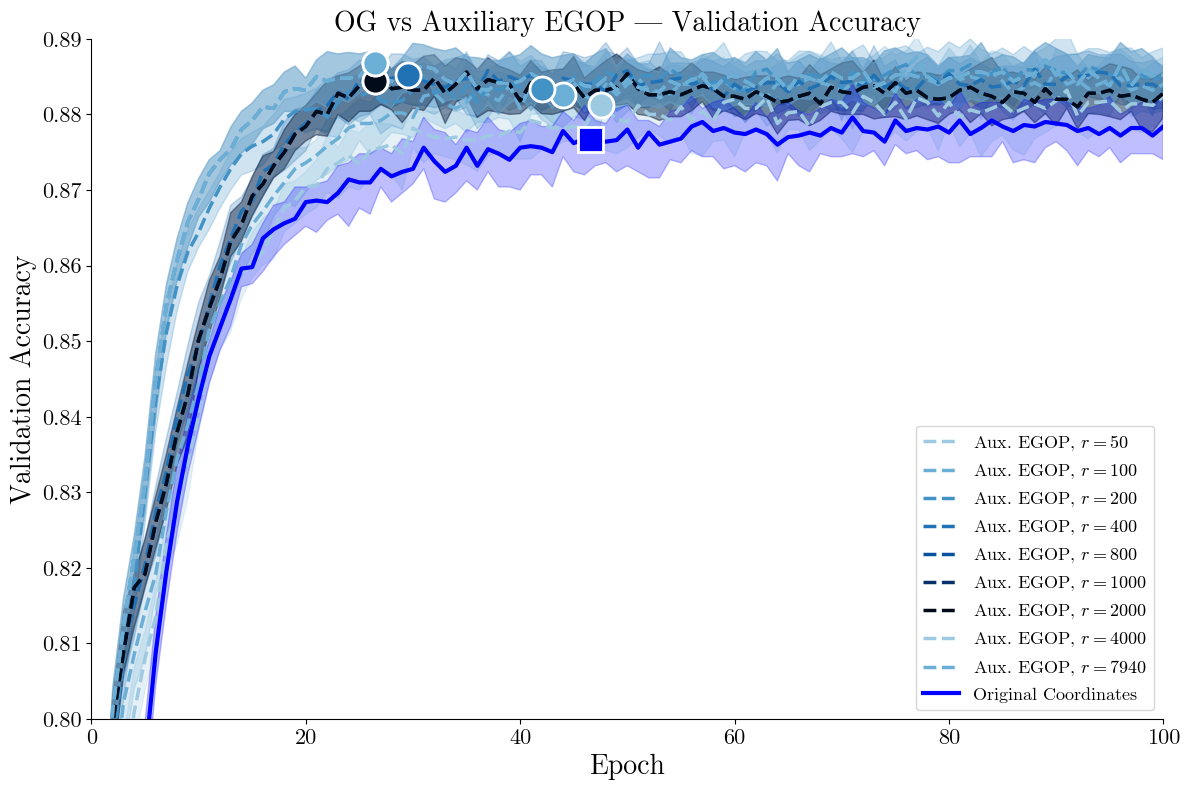

In [6]:
# Zoom into high-acc region
fig, ax = plt.subplots(figsize=(12, 8))
pa.plot_val_acc_curves(
    df, rsvd_values=rsvd_values, ax=ax,
    xlim=(0, 100),
    ylim=(0.80, 0.89),
)
plt.tight_layout()
plt.show()

## 4. Loss curves (log scale)

Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


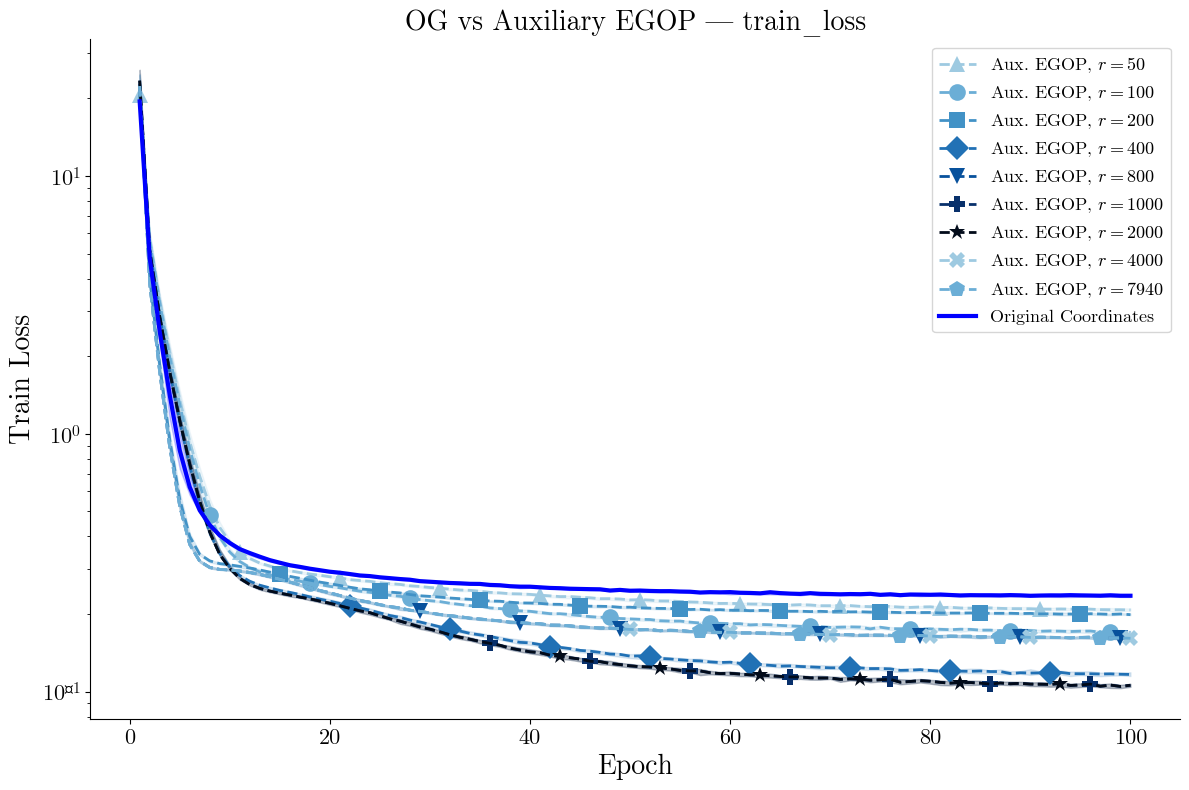

In [7]:
fig, ax = plt.subplots(figsize=(12, 8))
pa.plot_loss_curves(df, rsvd_values=rsvd_values, loss_col='train_loss', ax=ax)
plt.tight_layout()
plt.savefig('figures/aux_v2_train_loss.pdf', bbox_inches='tight')
plt.show()

## 5. Convergence time boxplot

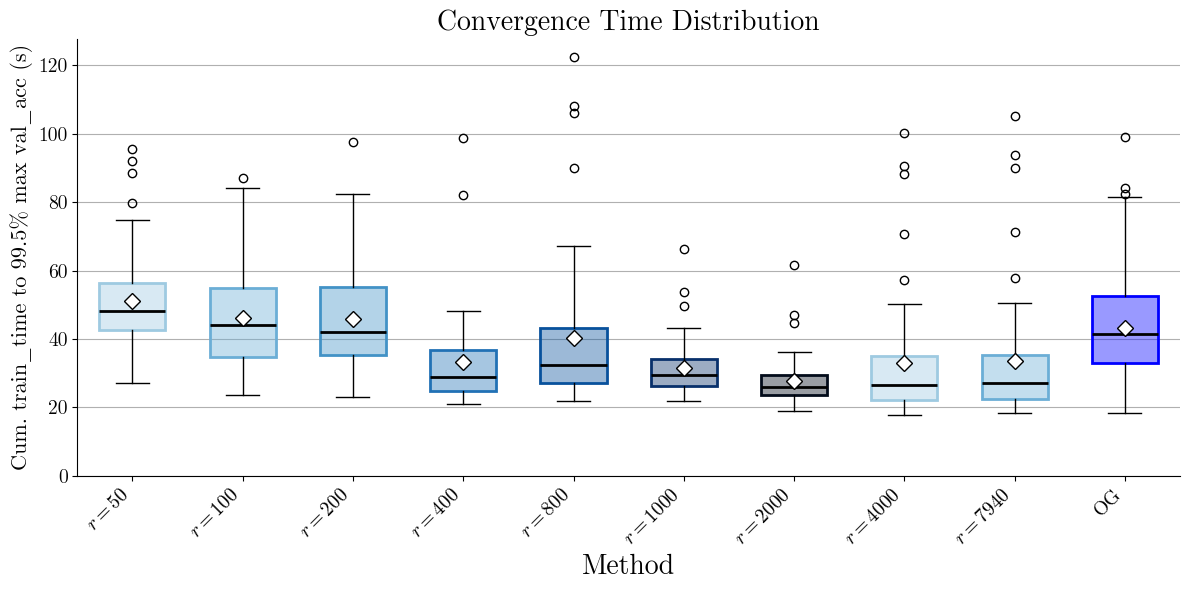

In [8]:
fig, ax = plt.subplots(figsize=(12, 6))
pa.plot_convergence_time_box(df, rsvd_values=rsvd_values, target_frac=0.995, ax=ax)
plt.tight_layout()
plt.savefig('figures/aux_v2_convergence_time.pdf', bbox_inches='tight')
plt.show()

## 6. Combined main figure (val acc + convergence time)

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(22, 8))
pa.plot_val_acc_curves(df, rsvd_values=rsvd_values, ax=ax1, ylim=(0.80, 0.89))
pa.plot_convergence_time_box(df, rsvd_values=rsvd_values, target_frac=0.995, ax=ax2)
plt.tight_layout()
plt.savefig('figures/aux_v2_main_figure.pdf', bbox_inches='tight')
plt.show()